In [1]:
import pandas as pd
import platform
import matplotlib.pyplot as plt

In [2]:
offline = pd.read_csv('../csv/card/오프라인.csv', encoding='cp949')

In [3]:
offline.head()

,crym,tco_btc_nm,ma_fem_dc,agegrp_dc,tco_btc_u_ct,tco_btc_u_am
0,201901,백화점,1,1,1,7.600000e+03
1,201901,백화점,1,10,379,1.945872e+07
2,201901,백화점,1,20,45173,4.747711e+09
3,201901,백화점,1,30,271858,2.791826e+10
4,201901,백화점,1,40,391109,3.791149e+10


In [4]:
# 항목 정의서 엑셀 파일을 로드
col_info = pd.read_excel('../csv/card/(수정)(항목정의서)유통+업종+카드소비트랜드+데이터_20211101.xlsx')

In [7]:
col_info

,데이터 컬럼,데이터 컬럼 설명,데이터 예시
0,기준년월,조회하고자 하는 기준 연도와 월,202104
1,업종 구분,"유통 업종(백화점, 할인점, 슈퍼마켓, 편의점)",백화점
2,성별,남자/여자 성별 구분\n남자 : 1 / 여자 : 2 / 남녀무관 : 9 / 결측치 : -,1
3,연령대,10세 단위로 구분한 연령대,10
4,이용 건수,이용 건수 합계,15
5,이용 금액,이용 금액 합계,51410


In [8]:
offline.columns = col_info['데이터 컬럼'].to_list()

In [9]:
offline.head(1)

,기준년월,업종 구분,성별,연령대,이용 건수,이용 금액
0,201901,백화점,1,1,1,7600.0


In [10]:
offline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   기준년월    2648 non-null   int64  
 1   업종 구분   2648 non-null   object 
 2   성별      2648 non-null   int64  
 3   연령대     2648 non-null   int64  
 4   이용 건수   2648 non-null   int64  
 5   이용 금액   2648 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 124.2+ KB


In [11]:
# 항목 정의서를 기준으로 성별에서 '-'가 결측치이다.
# '-'의 개수를 확인
# 조건식을 이용한다. 성별데이터에서 '-'와 같은 데이터
(offline['성별'] == '-').sum()

np.int64(0)

In [12]:
# 성별 데이터에서 데이터들의 개수를 확인
offline['성별'].value_counts()

성별
2    1336
1    1312
Name: count, dtype: int64

In [10]:
# 성별에 1, 2만 존재하는가? -> 1 이거나 (or) 2 인 경우
# 포함 여부 -> isin()
offline['성별'].isin([1,2]).all()

np.True_

In [11]:
# 고유값을 출력하자
offline['성별'].unique()

array([1, 2])

In [12]:
# 기준년월 데이터의 타입을 시계열데이터로 변경
# datetime 라이브러리 안에 strptime() 함수를 이용하여 변경
# pandas 안에 Series에서 제공하는 to_datetime() 함수를 이용하여 변경

In [13]:
from datetime import datetime

In [20]:
# datetime안에 strptime() -> 문자를 시계열 데이터로 변환
datetime.strptime(str(offline['기준년월'][0]), '%Y%m')

datetime.datetime(2019, 1, 1, 0, 0)

In [21]:
offline['기준년월'].map(
    lambda x : datetime.strptime(str(x), '%Y%m')
)

0      2019-01-01
1      2019-01-01
2      2019-01-01
3      2019-01-01
4      2019-01-01
          ...    
2643   2021-09-01
2644   2021-09-01
2645   2021-09-01
2646   2021-09-01
2647   2021-09-01
Name: 기준년월, Length: 2648, dtype: datetime64[ns]

In [22]:
# Series에 내장된 to_datetime()
# format 매개변수 존재 -> 선택항목 (pandas에는 범용적으로 사용이 되는 시계열 포멧이 존재)
offline['기준년월'] = pd.to_datetime(offline['기준년월'], format='%Y%m')

In [24]:
offline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   기준년월    2648 non-null   datetime64[ns]
 1   업종 구분   2648 non-null   object        
 2   성별      2648 non-null   int64         
 3   연령대     2648 non-null   int64         
 4   이용 건수   2648 non-null   int64         
 5   이용 금액   2648 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 124.2+ KB


In [ ]:
# 파생변수 생성 -> 월 컬럼 생성 -> 기준년월에서 월만 따로 추출
# 시계열 데이터에서 월을 추출한다. (strftime())
offline['기준년월'].map(
    lambda x : x.strftime('%m')
)

0       01
1       01
2       01
3       01
4       01
        ..
2643    09
2644    09
2645    09
2646    09
2647    09
Name: 기준년월, Length: 2648, dtype: object

In [26]:
# Series에서 문자열(str), 시계열(dt) 메소드에 접근하는 방법
offline['기준년월'].dt.strftime('%m')

0       01
1       01
2       01
3       01
4       01
        ..
2643    09
2644    09
2645    09
2646    09
2647    09
Name: 기준년월, Length: 2648, dtype: object

In [ ]:
offline['기준월'] = offline['기준년월'].dt.month
offline

In [29]:
# 기준월 별 이용금액의 평균을 막대그래프 표시
month_df = offline[['기준월', '이용 금액']].groupby('기준월').mean()
month_df

,이용 금액
기준월,
1,1.074901e+10
2,9.589884e+09
3,1.041977e+10
4,1.056234e+10
5,1.122180e+10
6,1.054029e+10
7,1.023200e+10
8,1.048811e+10
9,1.071814e+10


In [30]:
# 그래프의 한글 깨짐 방지
if platform.system() == 'Darwin':
    plt.rc('font', family = 'AppleGothic')
else:
    plt.rc('font', family = 'Malgun Gothic')

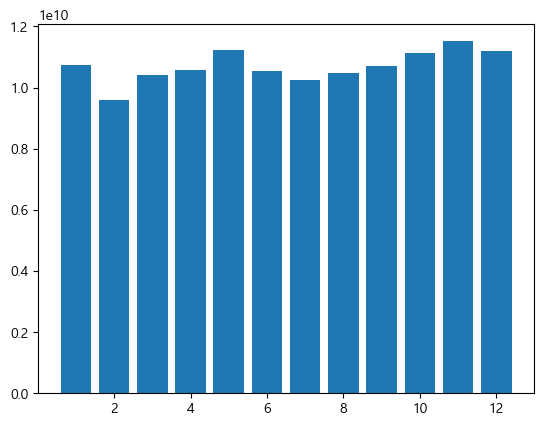

In [32]:
plt.bar(month_df.index, month_df['이용 금액'])
plt.show()

<Axes: xlabel='기준월'>

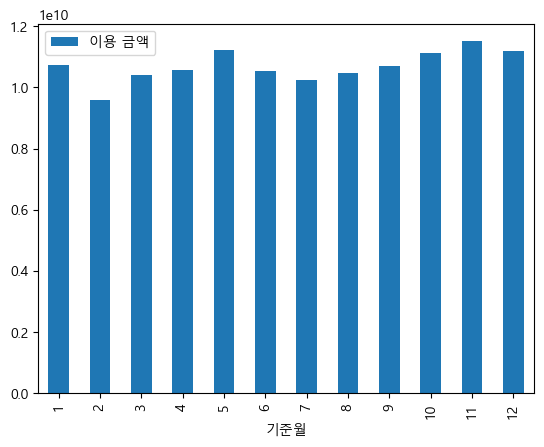

In [33]:
month_df.plot(kind='bar')

<Axes: xlabel='기준월'>

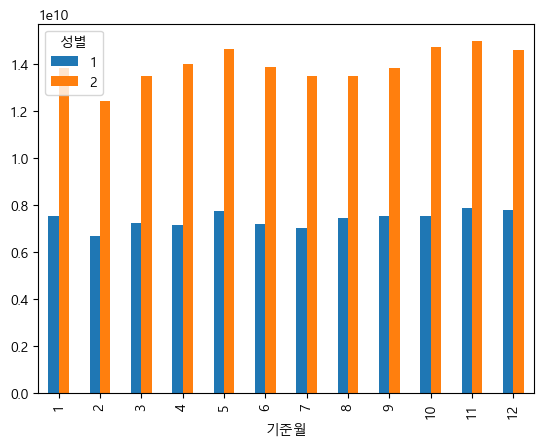

In [34]:
# 월별, 성별을 기준으로 이용금액의 평균을 그래프 표시
pd.pivot_table(
    offline,
    index= '기준월',
    columns = '성별',
    values = '이용 금액',
    aggfunc = 'mean'
).plot(kind='bar')

In [35]:
# 기준년월별 업종별로 이용 금액의 합계를 그래프(선 그래프)로 표시
offline['업종 구분'].unique()

array(['백화점', '할인점', '슈퍼마켓', '편의점'], dtype=object)

<Axes: xlabel='기준년월'>

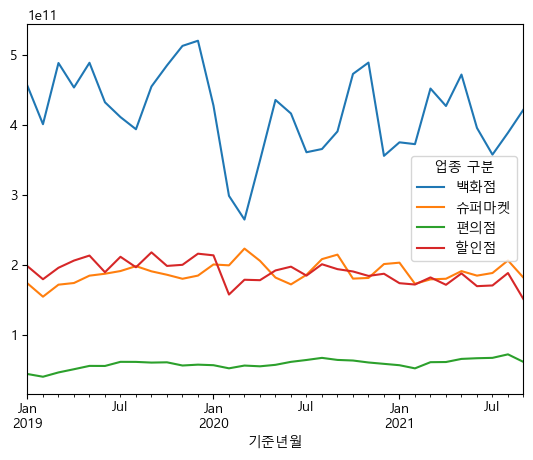

In [36]:
pd.pivot_table(
    offline,
    index = '기준년월',
    columns = '업종 구분',
    values = '이용 금액',
    aggfunc = 'sum'
).plot()

In [37]:
group_data = offline[['기준년월', '업종 구분', '이용 금액']].groupby(['기준년월', '업종 구분']).sum()

In [ ]:
group_data.plot(figsize = (20, 8))

<Axes: xlabel='기준년월'>

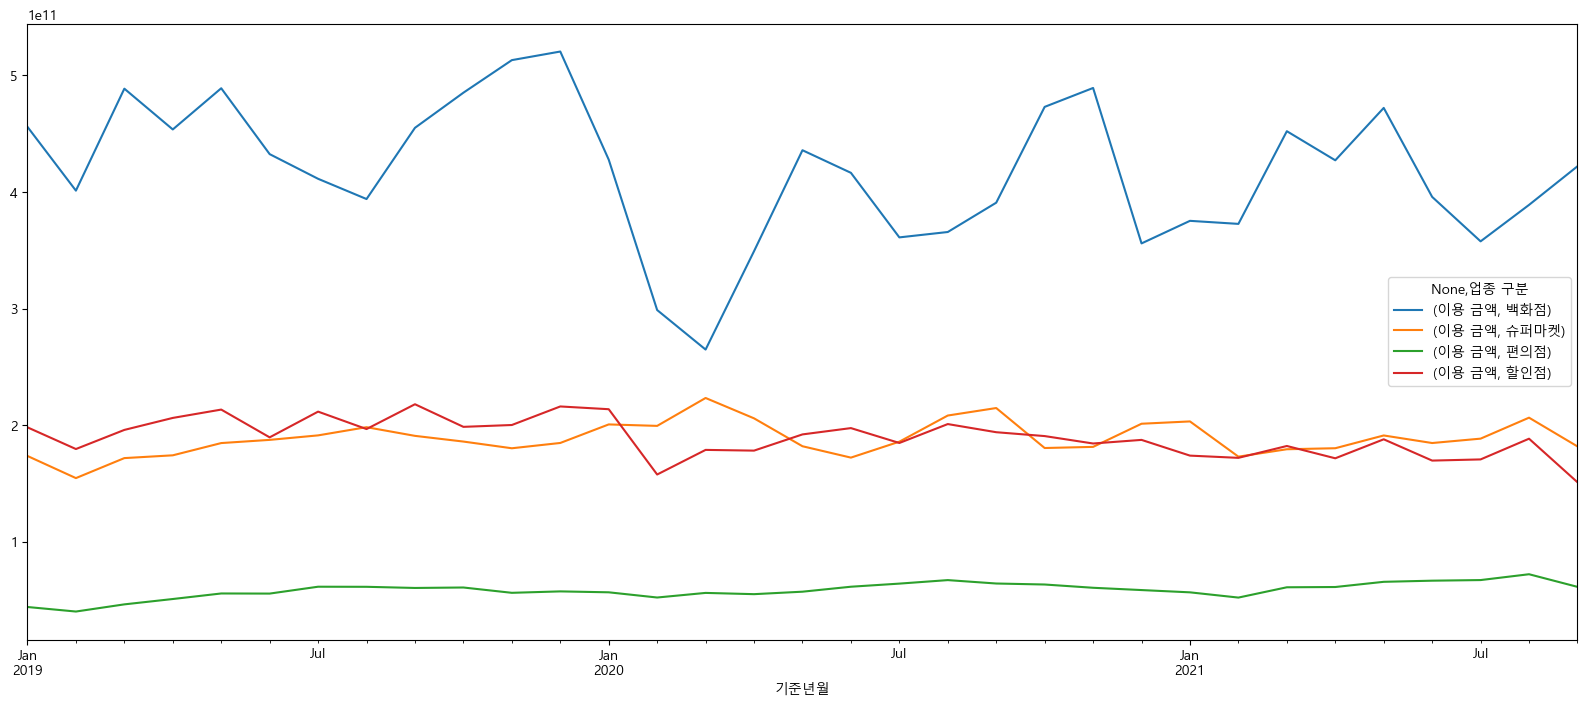

In [43]:
group_data.unstack().plot(figsize = (20, 8))

In [44]:
# 연령대 데이터가 어떤 데이터가 있는지 확인
offline['연령대'].value_counts()

연령대
10    264
20    264
30    264
70    264
40    264
50    264
60    264
90    264
80    264
0     233
1      39
Name: count, dtype: int64

In [45]:
# 파생 변수 -> 건당 이용금액
offline['건당이용금액'] = offline['이용 금액'] / offline['이용 건수']

In [ ]:
pd.pivot_table(
    offline,
    index = '성별',
    values = '건당이용금액',
    aggfunc = 'mean'
).plot(kind = 'bar')

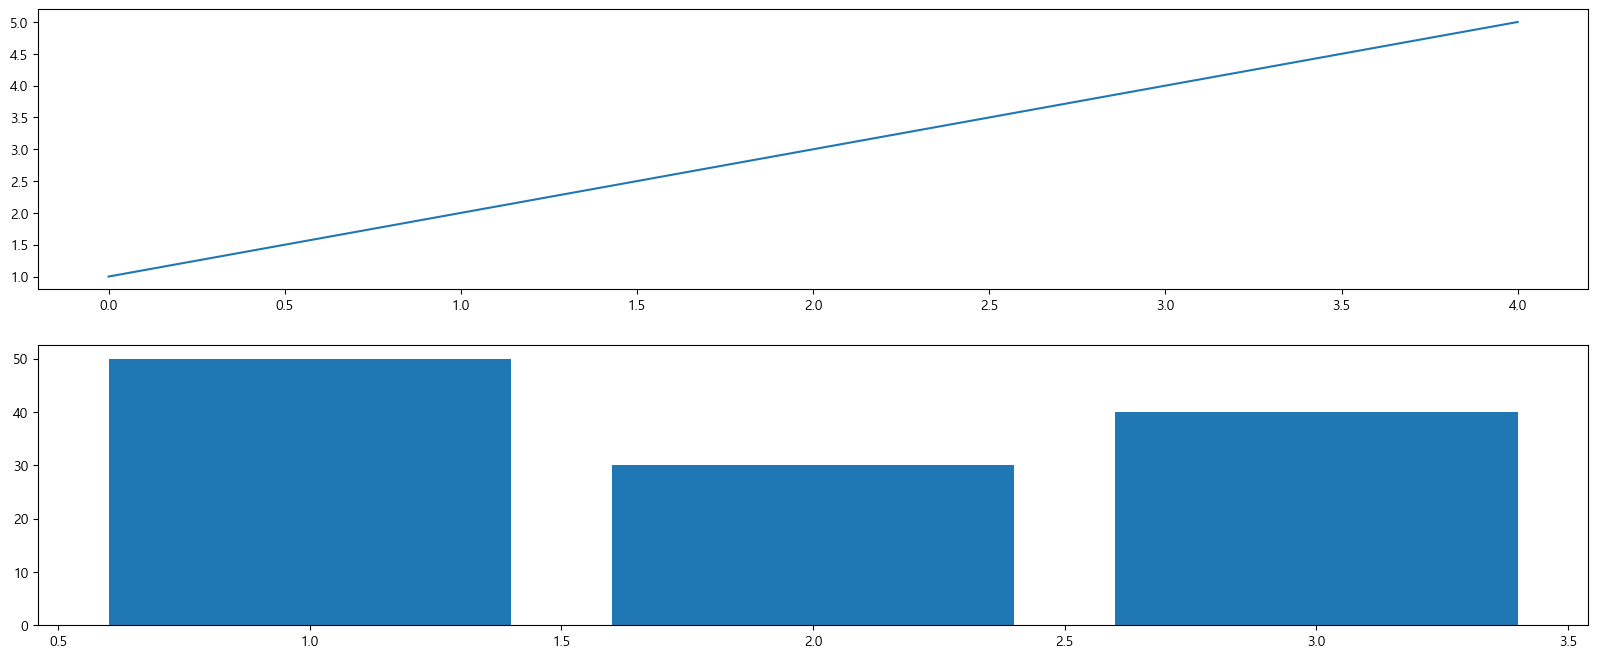

In [49]:
# matplot에서 여러개의 영역을 나눠서 그래프 그린다.
plt.figure(figsize=(20, 8))
# subplot(row(행의 개수), col(열의 개수), position(위치))
plt.subplot(2, 1, 1)
plt.plot([1,2,3,4,5])
plt.subplot(2, 1, 2)
plt.bar([1, 2, 3], [50, 30, 40])
plt.show()

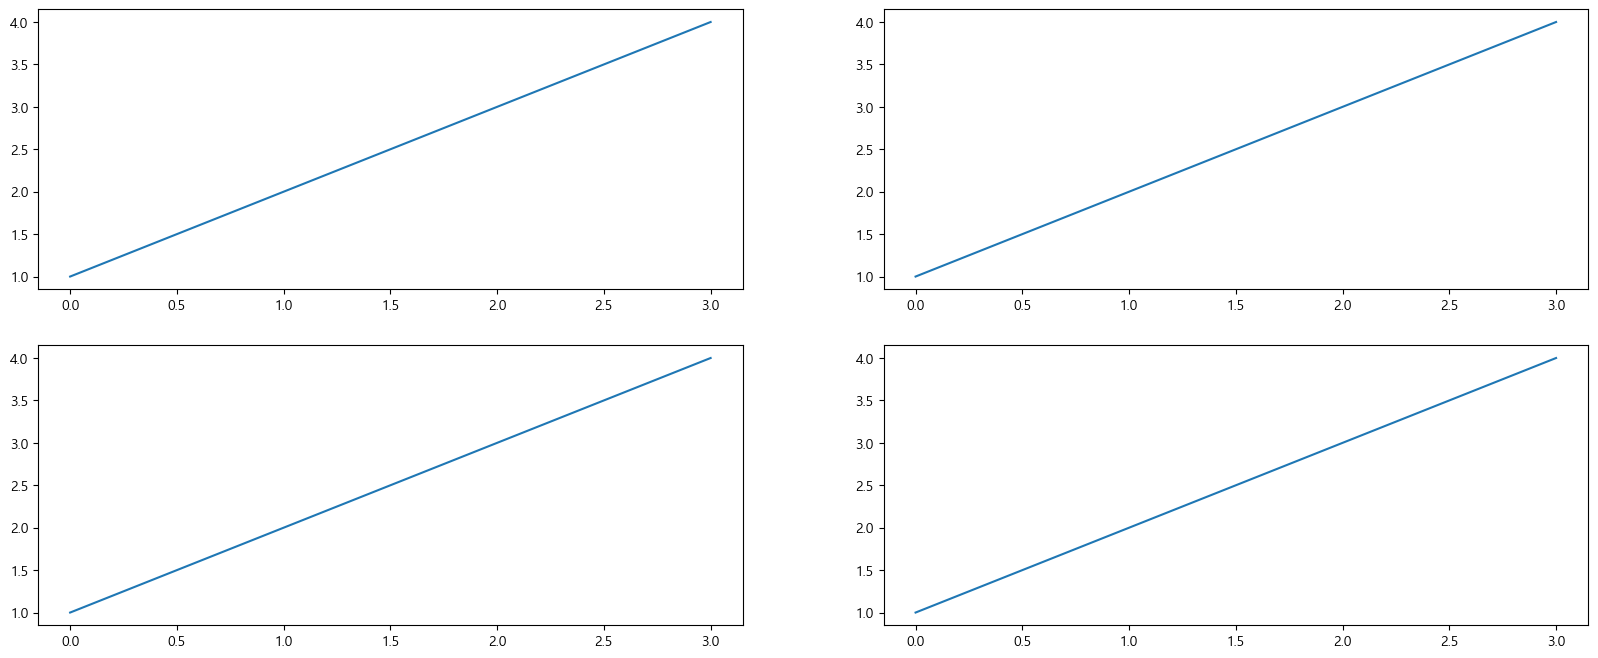

In [34]:
# subplots() -> 영역을 나눠주는 함수 -> 영역을 나눈 캔버스를 생성 -> 앞에서 생성한 캔버스의 크기는 초기화하고 새로 생성
fig, axes = plt.subplots(2, 2, figsize= (20, 8))

axes[0][0].plot([1,2,3,4])
axes[0][1].plot([1,2,3,4])
axes[1][0].plot([1,2,3,4])
axes[1][1].plot([1,2,3,4])

In [53]:
# 연령대 별로 그래프를 따로 생성
group_data2 = pd.pivot_table(
    offline,
    index = '기준년월',
    columns= '연령대',
    values='이용 금액',
    aggfunc='sum'
)
group_data2

연령대,0,1,10,20,30,40,50,60,70,80,90
기준년월,,,,,,,,,,,
2019-01-01,910780.0,389090.0,224014040.0,3.429963e+10,1.769725e+11,2.826641e+11,2.354251e+11,1.081785e+11,2.906987e+10,4.805910e+09,123124183.0
2019-02-01,296220.0,675100.0,215786616.0,3.260265e+10,1.622062e+11,2.558587e+11,2.059315e+11,9.106329e+10,2.385628e+10,3.759820e+09,102706591.0
2019-03-01,1249300.0,260830.0,245946517.0,3.697134e+10,1.886067e+11,2.937181e+11,2.403850e+11,1.082952e+11,2.966317e+10,4.746652e+09,126796384.0
2019-04-01,528930.0,29230.0,216882470.0,3.654784e+10,1.825348e+11,2.852485e+11,2.371059e+11,1.092047e+11,2.927507e+10,4.749677e+09,156413990.0
2019-05-01,1912110.0,305750.0,238182613.0,3.851212e+10,1.927688e+11,3.062182e+11,2.516052e+11,1.160723e+11,3.198842e+10,5.238787e+09,151060319.0
2019-06-01,3151300.0,336520.0,216216686.0,3.668917e+10,1.734532e+11,2.792607e+11,2.341569e+11,1.073443e+11,2.903758e+10,4.824611e+09,132063956.0
2019-07-01,1035060.0,31400.0,217303723.0,3.807959e+10,1.762154e+11,2.850977e+11,2.357340e+11,1.066718e+11,2.879290e+10,4.814125e+09,138286486.0
2019-08-01,1116940.0,404850.0,218841800.0,4.033300e+10,1.720801e+11,2.697329e+11,2.291537e+11,1.052268e+11,2.864153e+10,4.862635e+09,149288376.0
2019-09-01,1974100.0,460260.0,239944633.0,4.004589e+10,1.848110e+11,2.966084e+11,2.507156e+11,1.159495e+11,3.073454e+10,5.083968e+09,163789604.0


<Axes: xlabel='기준년월'>

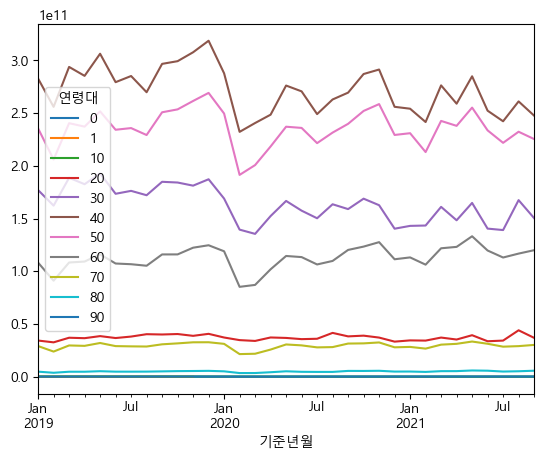

In [51]:
group_data2.plot()

In [52]:
len(
    offline['연령대'].unique()
)

11

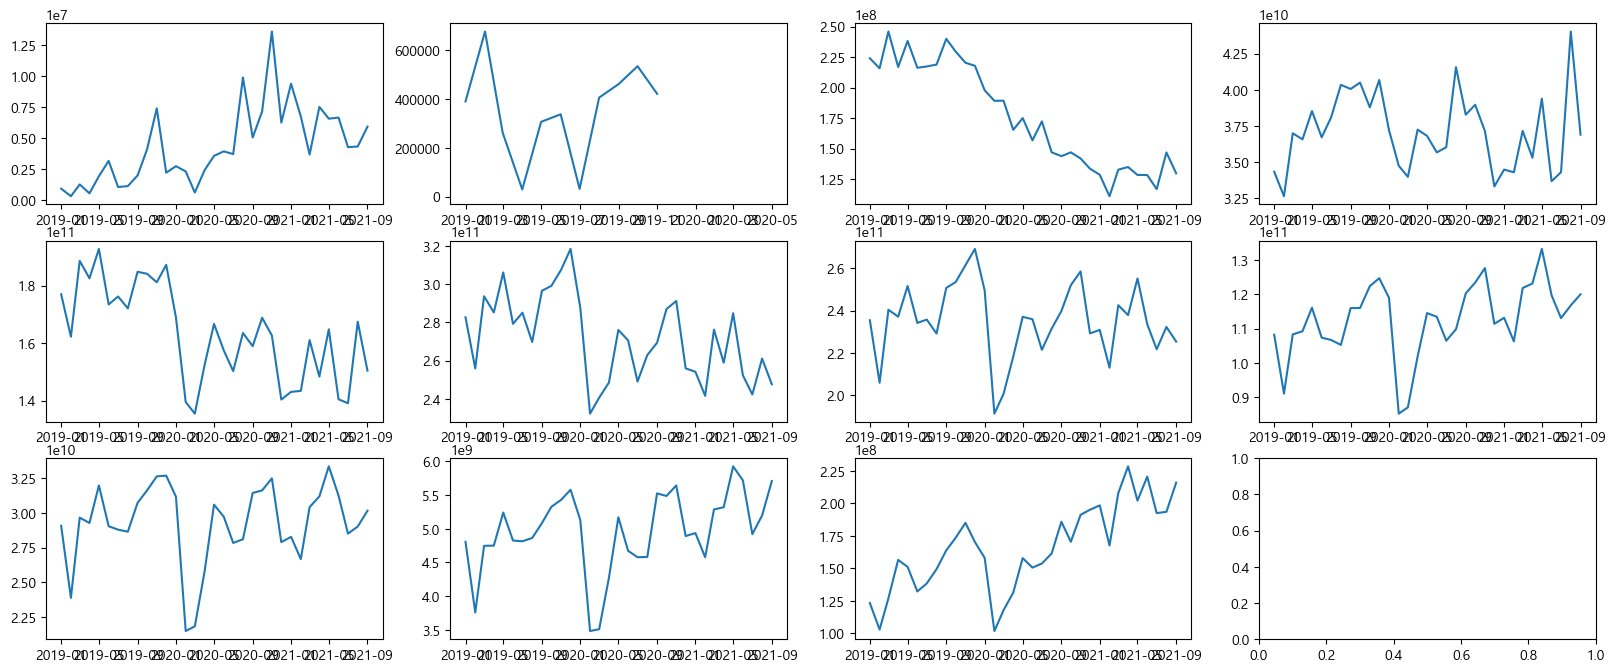

In [38]:
fig, axes = plt.subplots(3, 4, figsize = (20, 8))
for i in range( len (group_data2.columns)):
    # i -> 0부터 10까지 대입
    # row 위치의 조건은? -> 4로 나눈 몫
    row = i // 4
    # col 위치의 조건은? -> 4로 나눈 나머지
    cols = i % 4
    axes[row][cols].plot(group_data2.iloc[:,i])

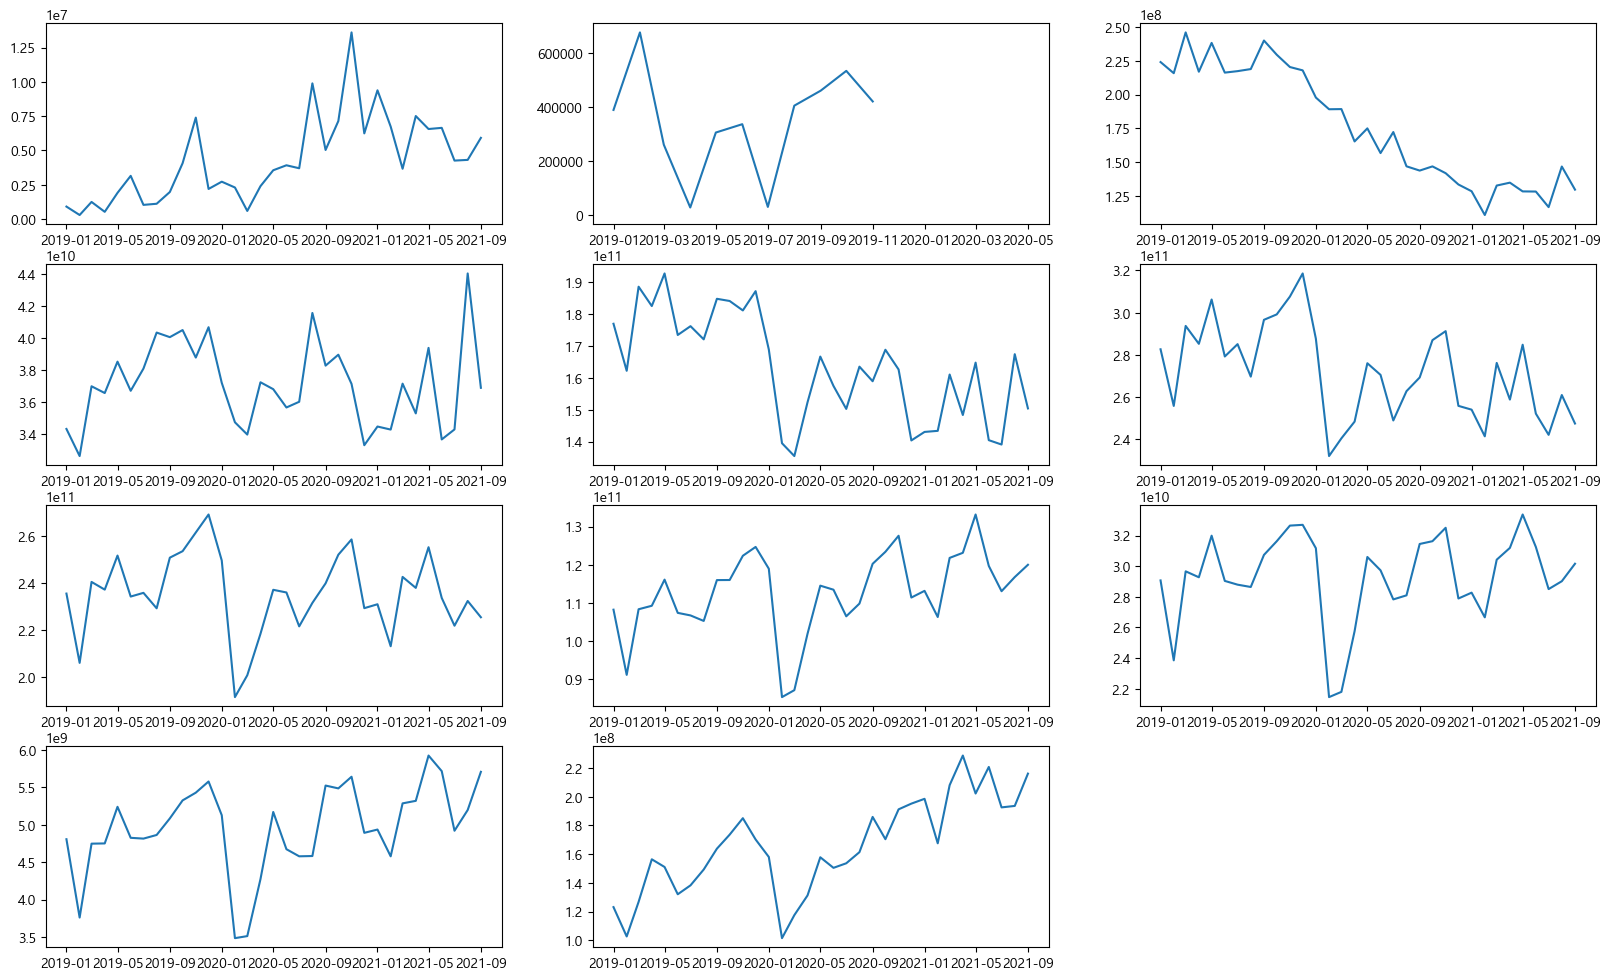

In [39]:
# 행을 4개로 열을 3개로 해서 subplot()을 이용
# subplot(row, cols, position) -> 위치의 값은 좌에서 우로 위에서 아래로 위치가 잡힘

# 캔버스의 사이즈 지정
plt.figure(figsize = (20, 12))
for i in range(len(group_data2.columns)):
    plt.subplot(4, 3, i+1)
    plt.plot(group_data2.iloc[:, i])
plt.show()

### 문제
1. offline 데이터에서 업종, 성별 별로 총 이용금액의 합계 라인 그래프로 표시
    - 8개 데이터를 각각 그래프를 생성
    - subplot(), subplots()를 이용해서 하나의 캔버스에 그래프를 생성
    - 생성된 그래프를 이미지로 저장
    - 행을 4, 열은 2게

In [40]:
offline.head(5)

,기준년월,업종 구분,성별,연령대,이용 건수,이용 금액,기준월,건당이용금액
0,2019-01-01,백화점,1,1,1,7.600000e+03,1,7600.000000
1,2019-01-01,백화점,1,10,379,1.945872e+07,1,51342.269129
2,2019-01-01,백화점,1,20,45173,4.747711e+09,1,105100.635357
3,2019-01-01,백화점,1,30,271858,2.791826e+10,1,102694.279892
4,2019-01-01,백화점,1,40,391109,3.791149e+10,1,96933.301601


In [41]:
offline['업종 구분'].value_counts()

업종 구분
편의점     667
백화점     664
슈퍼마켓    663
할인점     654
Name: count, dtype: int64

In [ ]:
group_data3 = offline[['업종 구분', '성별', '이용 금액']].groupby(['업종 구분', '성별']).sum()

이용 금액
업종 구분 성별              
백화점   1   3.937261e+12
      2   9.855847e+12
슈퍼마켓  1   2.356114e+12
      2   3.865891e+12
편의점   1   1.060329e+12
      2   8.714579e+11
할인점   1   2.309021e+12
      2   3.942937e+12

In [43]:
pd.pivot_table(
    offline,
    index = '기준년월',
    columns = ['성별', '업종 구분'],
    values = '이용 금액',
    aggfunc= 'sum'
)

성별                     1                                            \
업종 구분                백화점          슈퍼마켓           편의점           할인점   
기준년월                                                                 
2019-01-01  1.243582e+11  6.315280e+10  2.337134e+10  7.167173e+10   
2019-02-01  1.105301e+11  5.722725e+10  2.134192e+10  6.524339e+10   
2019-03-01  1.326044e+11  6.287926e+10  2.490085e+10  6.927964e+10   
2019-04-01  1.259369e+11  6.363679e+10  2.704512e+10  7.325285e+10   
2019-05-01  1.340792e+11  6.746316e+10  2.965534e+10  7.534786e+10   
2019-06-01  1.190628e+11  6.892544e+10  2.965438e+10  6.738769e+10   
2019-07-01  1.134018e+11  7.053646e+10  3.293398e+10  7.648837e+10   
2019-08-01  1.089727e+11  7.323192e+10  3.273994e+10  7.127913e+10   
2019-09-01  1.265471e+11  7.129038e+10  3.262400e+10  8.047491e+10   
2019-10-01  1.352275e+11  6.881618e+10  3.267945e+10  6.978190e+10   
2019-11-01  1.432718e+11  6.619541e+10  3.042560e+10  7.052068e+10   
2019-12-01  1.476660e+11  6.895783e+10  3.106922e+10  7.959933e+10   
2020-01-01  1.215868e+11  7.523182e+10  3.073478e+10  8.027681e+10   
2020-02-01  8.443177e+10  7.455573e+10  2.843173e+10  5.837546e+10   
2020-03-01  7.669288e+10  8.455420e+10  3.144350e+10  6.838499e+10   
2020-04-01  1.004527e+11  7.468819e+10  3.025154e+10  6.565374e+10   
2020-05-01  1.236489e+11  7.493677e+10  3.220464e+10  7.211564e+10   
2020-06-01  1.175369e+11  7.097937e+10  3.475285e+10  7.397484e+10   
2020-07-01  1.013608e+11  7.178268e+10  3.543868e+10  6.809146e+10   
2020-08-01  1.064368e+11  7.978506e+10  3.680216e+10  7.609642e+10   
2020-09-01  1.137736e+11  8.093672e+10  3.569012e+10  7.268789e+10   
2020-10-01  1.360356e+11  6.968048e+10  3.494010e+10  7.048823e+10   
2020-11-01  1.417310e+11  6.889189e+10  3.346197e+10  6.858586e+10   
2020-12-01  1.063057e+11  7.726372e+10  3.275718e+10  7.137667e+10   
2021-01-01  1.119112e+11  7.867021e+10  3.161348e+10  6.727506e+10   
2021-02-01  1.109798e+11  6.700087e+10  2.925879e+10  6.648995e+10   
2021-03-01  1.309254e+11  6.916147e+10  3.428334e+10  6.804542e+10   
2021-04-01  1.230141e+11  6.878899e+10  3.407806e+10  6.317209e+10   
2021-05-01  1.384557e+11  7.377828e+10  3.646660e+10  7.102332e+10   
2021-06-01  1.118231e+11  7.052494e+10  3.696821e+10  6.252466e+10   
2021-07-01  1.066251e+11  7.260776e+10  3.741981e+10  6.402186e+10   
2021-08-01  1.235541e+11  7.952493e+10  4.012404e+10  7.300243e+10   
2021-09-01  1.283211e+11  7.045715e+10  3.476593e+10  5.703062e+10   

성별                     2                                            
업종 구분                백화점          슈퍼마켓           편의점           할인점  
기준년월                                                                
2019-01-01  3.315373e+11  1.104603e+11  2.071225e+10  1.265001e+11  
2019-02-01  2.906615e+11  9.741180e+10  1.885490e+10  1.143270e+11  
2019-03-01  3.560477e+11  1.089138e+11  2.144601e+10  1.266887e+11  
2019-04-01  3.277354e+11  1.105415e+11  2.389072e+10  1.330010e+11  
2019-05-01  3.549244e+11  1.172264e+11  2.603593e+10  1.380631e+11  
2019-06-01  3.134471e+11  1.184984e+11  2.593874e+10  1.222037e+11  
2019-07-01  2.979423e+11  1.207452e+11  2.854916e+10  1.351650e+11  
2019-08-01  2.850100e+11  1.250796e+11  2.866631e+10  1.254207e+11  
2019-09-01  3.285276e+11  1.195802e+11  2.779730e+10  1.375135e+11  
2019-10-01  3.499692e+11  1.171599e+11  2.813239e+10  1.288181e+11  
2019-11-01  3.698547e+11  1.140359e+11  2.582605e+10  1.296578e+11  
2019-12-01  3.728330e+11  1.158204e+11  2.640417e+10  1.364898e+11  
2020-01-01  3.061954e+11  1.254491e+11  2.595424e+10  1.334494e+11  
2020-02-01  2.143414e+11  1.248730e+11  2.379342e+10  9.934166e+10  
2020-03-01  1.881877e+11  1.388059e+11  2.472866e+10  1.104471e+11  
2020-04-01  2.488126e+11  1.312061e+11  2.484554e+10  1.125593e+11  
2020-05-01  3.122018e+11  1.070313e+11  2.501183e+10  1.199994e+11  
2020-06-01  2.989344e+11  1.012321e+11  2.672170e+10  1.235510e+11  
2020-07-01  2.597413e+11  1.14

In [54]:
# groupby() 함수를 이용하기 전에 컬럼을 필터링 하고 그룹화 진행
# 그룹화를 진행하고 연산을 하기 전에 컬럼을 필터링
group_data3 = offline.groupby(['기준년월', '성별', '업종 구분'])['이용 금액'].sum()

In [55]:
group_data4 = offline[['기준년월', '성별', '업종 구분', '이용 금액']].groupby(['기준년월', '성별', '업종 구분']).sum()

In [56]:
group_data3 = group_data3.unstack().unstack()

In [57]:
group_data4.unstack()

이용 금액                                          
업종 구분                   백화점          슈퍼마켓           편의점           할인점
기준년월       성별                                                        
2019-01-01 1   1.243582e+11  6.315280e+10  2.337134e+10  7.167173e+10
           2   3.315373e+11  1.104603e+11  2.071225e+10  1.265001e+11
2019-02-01 1   1.105301e+11  5.722725e+10  2.134192e+10  6.524339e+10
           2   2.906615e+11  9.741180e+10  1.885490e+10  1.143270e+11
2019-03-01 1   1.326044e+11  6.287926e+10  2.490085e+10  6.927964e+10
...                     ...           ...           ...           ...
2021-07-01 2   2.510756e+11  1.158746e+11  2.976415e+10  1.066457e+11
2021-08-01 1   1.235541e+11  7.952493e+10  4.012404e+10  7.300243e+10
           2   2.654136e+11  1.269435e+11  3.206470e+10  1.154271e+11
2021-09-01 1   1.283211e+11  7.045715e+10  3.476593e+10  5.703062e+10
           2   2.937602e+11  1.113523e+11  2.659689e+10  9.404897e+10

[66 rows x 4 columns]

In [48]:
group_data3.loc[ : ,('백화점', 1)]

기준년월
2019-01-01    1.243582e+11
2019-02-01    1.105301e+11
2019-03-01    1.326044e+11
2019-04-01    1.259369e+11
2019-05-01    1.340792e+11
2019-06-01    1.190628e+11
2019-07-01    1.134018e+11
2019-08-01    1.089727e+11
2019-09-01    1.265471e+11
2019-10-01    1.352275e+11
2019-11-01    1.432718e+11
2019-12-01    1.476660e+11
2020-01-01    1.215868e+11
2020-02-01    8.443177e+10
2020-03-01    7.669288e+10
2020-04-01    1.004527e+11
2020-05-01    1.236489e+11
2020-06-01    1.175369e+11
2020-07-01    1.013608e+11
2020-08-01    1.064368e+11
2020-09-01    1.137736e+11
2020-10-01    1.360356e+11
2020-11-01    1.417310e+11
2020-12-01    1.063057e+11
2021-01-01    1.119112e+11
2021-02-01    1.109798e+11
2021-03-01    1.309254e+11
2021-04-01    1.230141e+11
2021-05-01    1.384557e+11
2021-06-01    1.118231e+11
2021-07-01    1.066251e+11
2021-08-01    1.235541e+11
2021-09-01    1.283211e+11
Name: (백화점, 1), dtype: float64

In [49]:
group_data3['백화점'][1]

기준년월
2019-01-01    1.243582e+11
2019-02-01    1.105301e+11
2019-03-01    1.326044e+11
2019-04-01    1.259369e+11
2019-05-01    1.340792e+11
2019-06-01    1.190628e+11
2019-07-01    1.134018e+11
2019-08-01    1.089727e+11
2019-09-01    1.265471e+11
2019-10-01    1.352275e+11
2019-11-01    1.432718e+11
2019-12-01    1.476660e+11
2020-01-01    1.215868e+11
2020-02-01    8.443177e+10
2020-03-01    7.669288e+10
2020-04-01    1.004527e+11
2020-05-01    1.236489e+11
2020-06-01    1.175369e+11
2020-07-01    1.013608e+11
2020-08-01    1.064368e+11
2020-09-01    1.137736e+11
2020-10-01    1.360356e+11
2020-11-01    1.417310e+11
2020-12-01    1.063057e+11
2021-01-01    1.119112e+11
2021-02-01    1.109798e+11
2021-03-01    1.309254e+11
2021-04-01    1.230141e+11
2021-05-01    1.384557e+11
2021-06-01    1.118231e+11
2021-07-01    1.066251e+11
2021-08-01    1.235541e+11
2021-09-01    1.283211e+11
Name: 1, dtype: float64

In [50]:
group_data3.iloc[:,0]

기준년월
2019-01-01    1.243582e+11
2019-02-01    1.105301e+11
2019-03-01    1.326044e+11
2019-04-01    1.259369e+11
2019-05-01    1.340792e+11
2019-06-01    1.190628e+11
2019-07-01    1.134018e+11
2019-08-01    1.089727e+11
2019-09-01    1.265471e+11
2019-10-01    1.352275e+11
2019-11-01    1.432718e+11
2019-12-01    1.476660e+11
2020-01-01    1.215868e+11
2020-02-01    8.443177e+10
2020-03-01    7.669288e+10
2020-04-01    1.004527e+11
2020-05-01    1.236489e+11
2020-06-01    1.175369e+11
2020-07-01    1.013608e+11
2020-08-01    1.064368e+11
2020-09-01    1.137736e+11
2020-10-01    1.360356e+11
2020-11-01    1.417310e+11
2020-12-01    1.063057e+11
2021-01-01    1.119112e+11
2021-02-01    1.109798e+11
2021-03-01    1.309254e+11
2021-04-01    1.230141e+11
2021-05-01    1.384557e+11
2021-06-01    1.118231e+11
2021-07-01    1.066251e+11
2021-08-01    1.235541e+11
2021-09-01    1.283211e+11
Name: (백화점, 1), dtype: float64

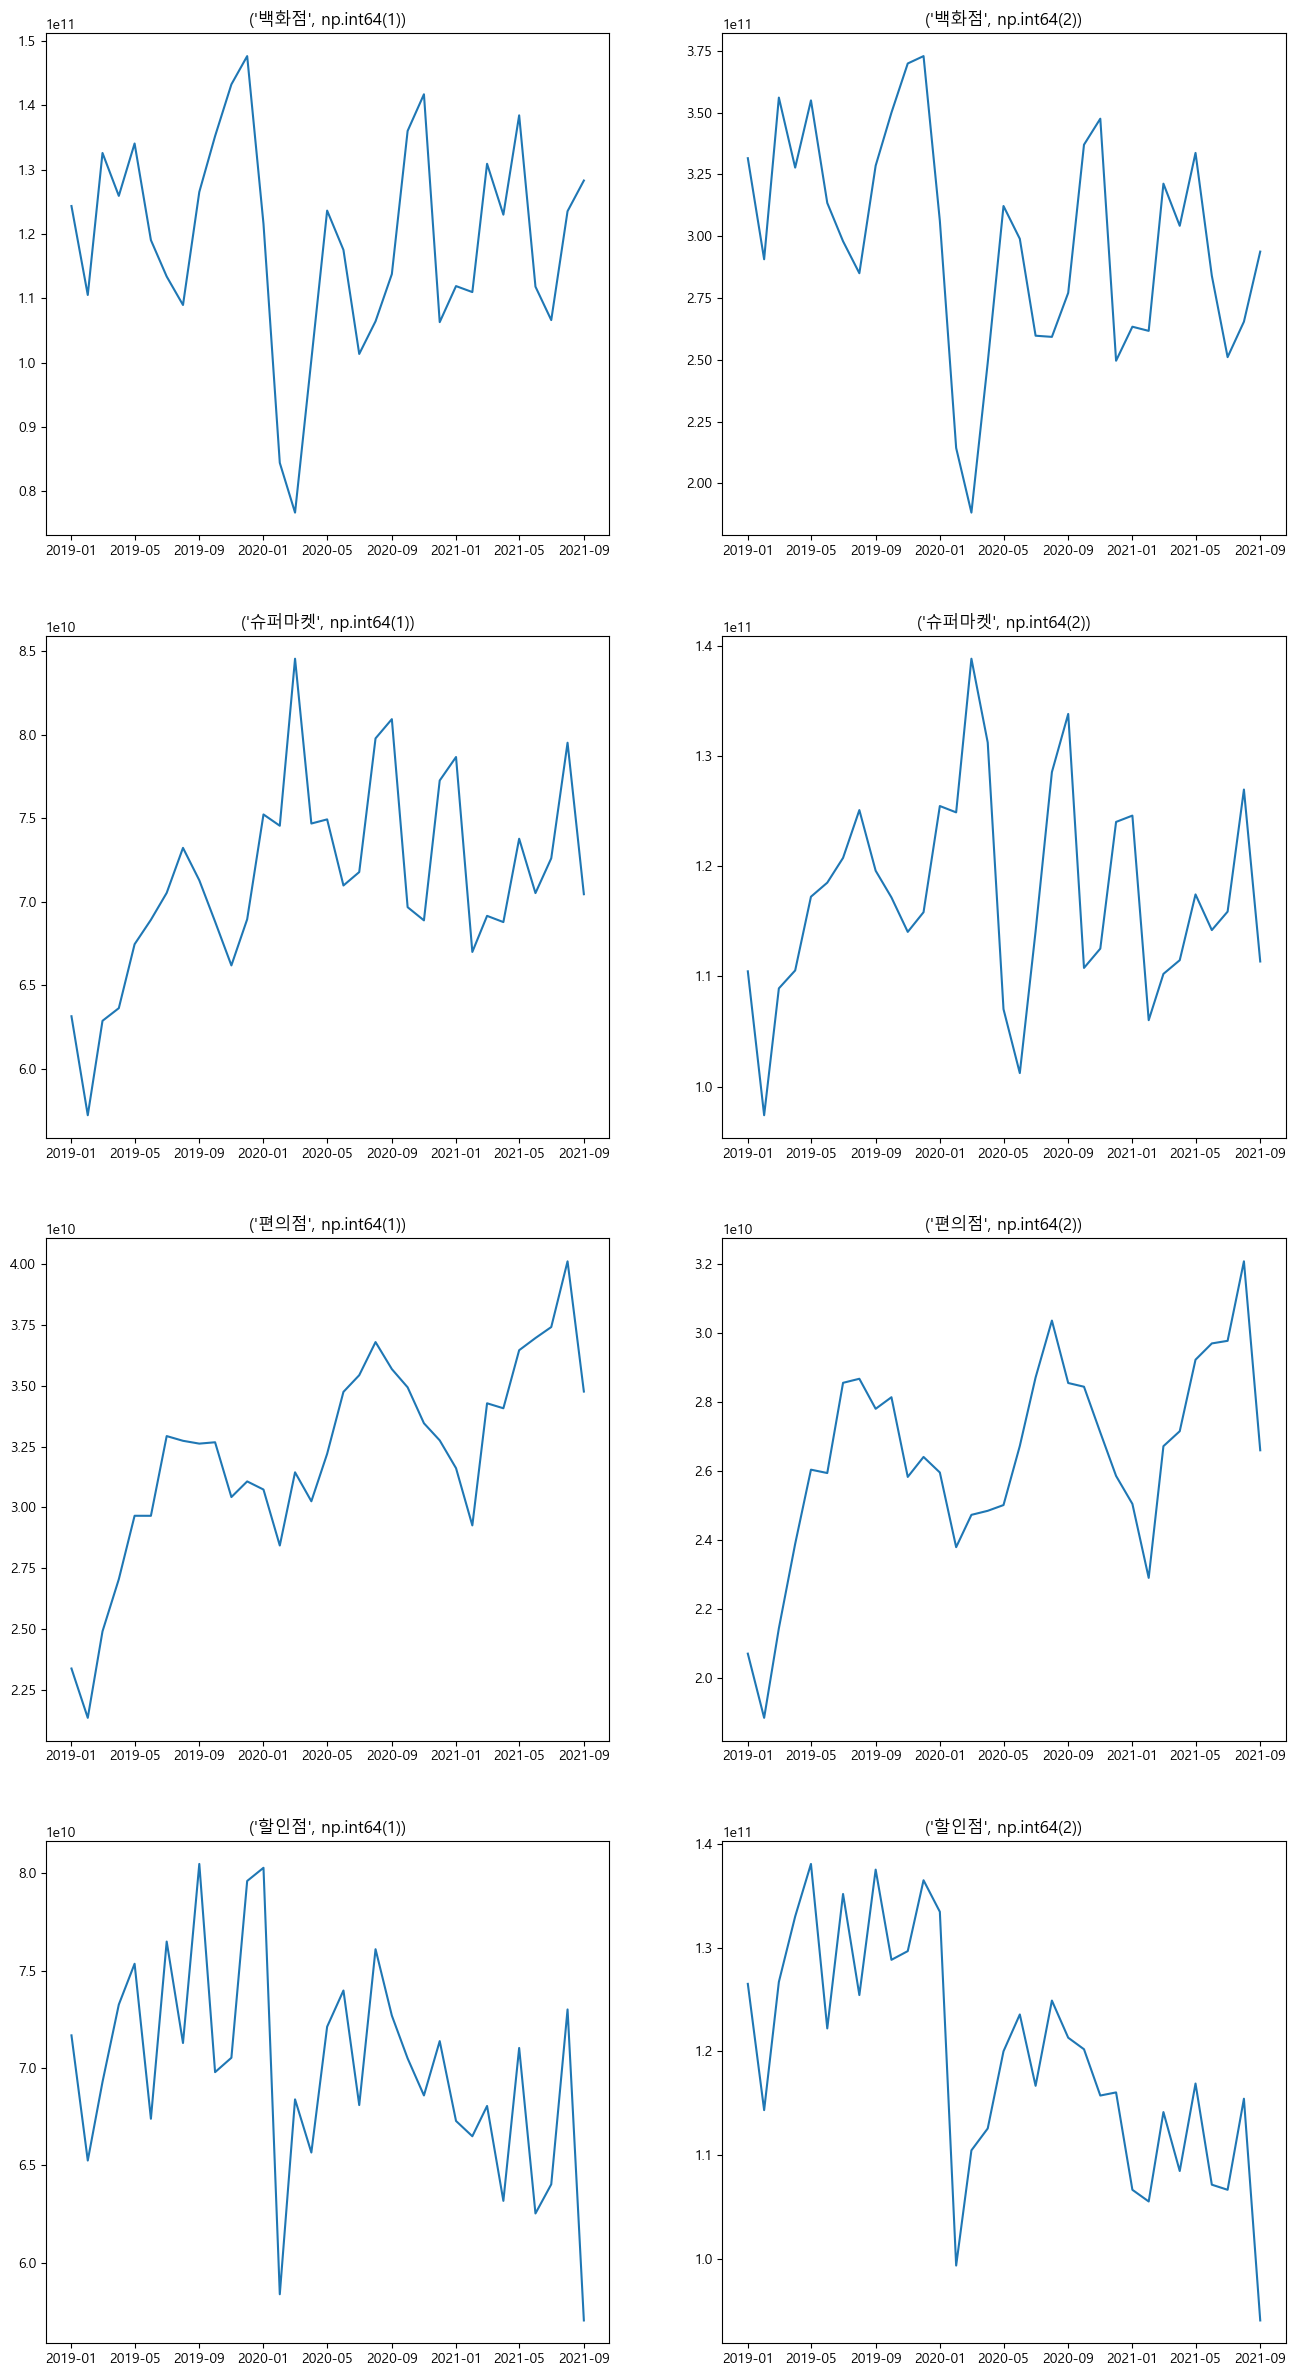

In [51]:
# subplot()
plt.figure(figsize = (16, 30))

# 반복 실행하면서 위치별로 그래프를 추가
for i in range(len(group_data3.columns)):
    plt.subplot(4, 2, i+1)
    plt.plot( group_data3.iloc[ : , i])
    # title 추가
    plt.title(group_data3.columns[i])
# plt의 의미는 -> 캔버스 -> 8장의 그래프가 포함되어 있는 캔버스 (가장 마지막에 만들어진 캔버스)
plt.savefig('subplot.png')
plt.show()

C:\Users\신재호\AppData\Local\Temp\ipykernel_6692\1067458404.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


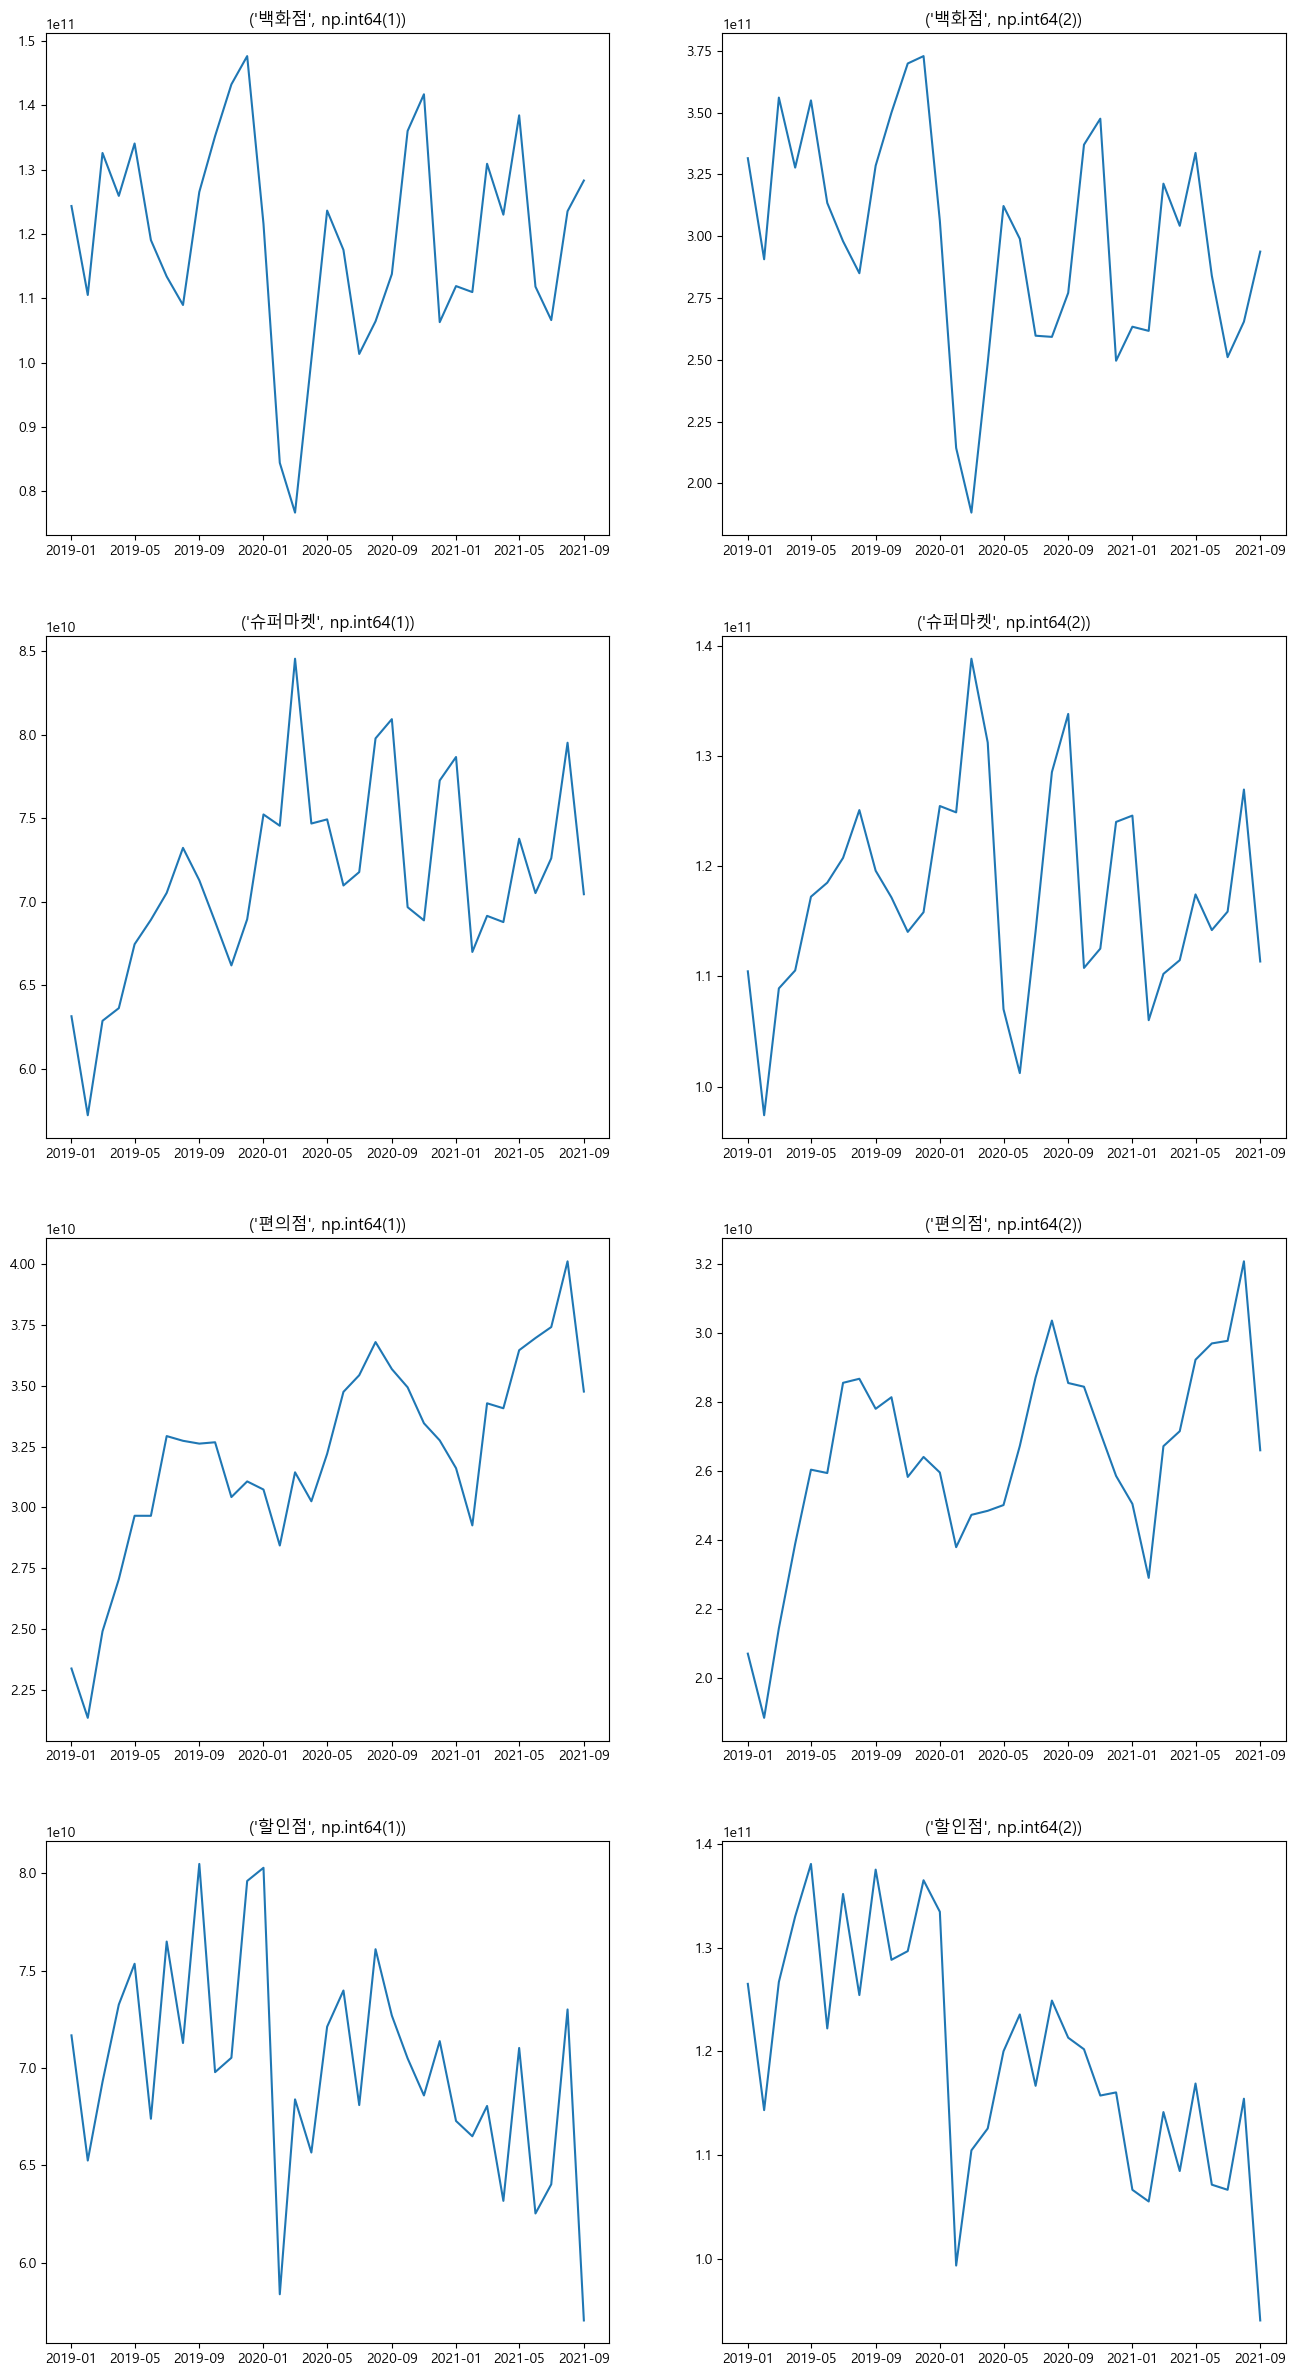

In [52]:
# subplots() 버전
row_num = 4
col_num = 2
# subplots() -> 2개의 데이터를 리턴 (캔버스, 영역)
# fig -> 캔버스
fig, axes = plt.subplots(row_num, col_num, figsize = (16, 30))

for i in range(len (group_data3.columns)):
    rows = i // col_num
    cols = i % col_num
    axes[rows][cols].plot(group_data3.iloc[ : , i])
    # 그래프에 이름을 넣어라
    # plt인 캔버스를 선택하는 것이 아니라 영역을 선택
    # plt.title(group_data3.columns[i])
    # axes 영역에서는 title() 함수가 존재하지 않는다. -> set_title() 함수를 이용
    axes[rows][cols].set_title(group_data3.columns[i])
fig.savefig('subplots.png')
fig.show()

- 오프라인, 온라인 데이터를 로드
- 데이터들을 확인
- 두개의 데이터프레임을 결합(유니언, 조인)
    - 유니언
        - 단순한 행 결합 ( 두개의 데이터프레임의 구조가 같은 경우 )
    - 조인
        - 특정컬럼의 데이터가 같은 경우 조건에 맞춰서 열을 결합
- 온라인에서 총 이용금액과 오프라인에서의 총 이용금액을 기간에 따라 어떻게 바뀌는가? 확인

In [58]:
offline = pd.read_csv("../csv/card/오프라인.csv", encoding='cp949')
online = pd.read_csv("../csv/card/온라인.csv", encoding='cp949')

In [59]:
offline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   crym          2648 non-null   int64  
 1   tco_btc_nm    2648 non-null   object 
 2   ma_fem_dc     2648 non-null   int64  
 3   agegrp_dc     2648 non-null   int64  
 4   tco_btc_u_ct  2648 non-null   int64  
 5   tco_btc_u_am  2648 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 124.2+ KB


In [60]:
online.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651 entries, 0 to 650
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   crym          651 non-null    int64
 1   ma_fem_dc     651 non-null    int64
 2   agegrp_dc     651 non-null    int64
 3   tco_btc_u_ct  651 non-null    int64
 4   tco_btc_u_am  651 non-null    int64
dtypes: int64(5)
memory usage: 25.6 KB


In [61]:
# 온라인 성별 컬럼에 9라는 데이터가 존재하는가?
online['ma_fem_dc'].describe()

count    651.000000
mean       1.499232
std        0.500384
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        2.000000
Name: ma_fem_dc, dtype: float64

In [62]:
online['ma_fem_dc'].value_counts()

ma_fem_dc
1    326
2    325
Name: count, dtype: int64

In [63]:
online.describe()

,crym,ma_fem_dc,agegrp_dc,tco_btc_u_ct,tco_btc_u_am
count,651.000000,651.000000,651.000000,6.510000e+02,6.510000e+02
mean,201998.135177,1.499232,45.631336,9.606536e+05,4.940927e+10
std,78.678490,0.500384,28.432958,1.443702e+06,6.914516e+10
min,201901.000000,1.000000,0.000000,1.000000e+00,5.000000e+02
25%,201909.000000,1.000000,20.000000,3.481500e+03,1.467190e+08
50%,202005.000000,1.000000,50.000000,1.969560e+05,1.449364e+10
75%,202101.000000,2.000000,70.000000,1.330438e+06,7.999589e+10
max,202109.000000,2.000000,90.000000,6.824744e+06,3.065816e+11


In [64]:
offline.describe()

,crym,ma_fem_dc,agegrp_dc,tco_btc_u_ct,tco_btc_u_am
count,2648.000000,2648.000000,2648.000000,2.648000e+03,2.648000e+03
mean,201996.672205,1.504532,44.878776,3.309869e+05,1.064912e+10
std,78.829105,0.500074,28.768254,4.645646e+05,1.755371e+10
min,201901.000000,1.000000,0.000000,1.000000e+00,1.500000e+03
25%,201909.000000,1.000000,20.000000,9.407500e+02,2.652966e+07
50%,202005.000000,2.000000,40.000000,1.053975e+05,2.589632e+09
75%,202101.000000,2.000000,70.000000,4.907440e+05,1.457397e+10
max,202109.000000,2.000000,90.000000,2.343320e+06,1.116790e+11


In [65]:
# 두개의 데이터프레임의 이름을 변경 
offline.columns = ['기준년월', '업종', '성별', '연령대' ,'이용건수', '이용금액']
online.columns = ['기준년월', '성별', '연령대', '이용건수', '이용금액']

In [66]:
# 두개의 데이터프레임의 구조가 약간 다르다. online 데이터에는 업종 컬럼이 존재x
# 결합하고 업종 결측치에 데이터를 채워주는 방법 
# online 업종 컬럼을 생성하고 그 후에 결합 

In [62]:
# 단순 결합 concat() -> 여러개의 데이터프레임을 결합 가능 ( 첫번째 인자에 데이터프레임 목록 입력 )
df = pd.concat( [ offline, online ], axis = 0, ignore_index=True )

In [67]:
# 단순 결합 concat() -> 여러개의 데이터프레임을 결합 가능 ( 첫번째 인자에 데이터프레임 목록 입력 )
df = pd.concat( [ offline, online ], axis = 0, ignore_index=True )

In [68]:
# df안에 업종 컬럼에 결측치를 특정한 값으로 대체 
df['업종'] = df['업종'].fillna('온라인')

In [69]:
# online에 업공 컬럼을 추가 하고 '온라인'으로 모두 채워준다. 
online['업종'] = '온라인'

In [70]:
online

,기준년월,성별,연령대,이용건수,이용금액,업종
0,201901,1,1,1,110685,온라인
1,201901,1,10,2333,98108225,온라인
2,201901,1,20,272915,13854081656,온라인
3,201901,1,30,1320227,82946127640,온라인
4,201901,1,40,1372052,95550848337,온라인
...,...,...,...,...,...,...
646,202109,2,50,3237324,181360535814,온라인
647,202109,2,60,1019719,70026626874,온라인
648,202109,2,70,159261,13091029631,온라인
649,202109,2,80,20094,1935122483,온라인


In [71]:
offline.columns

Index(['기준년월', '업종', '성별', '연령대', '이용건수', '이용금액'], dtype='object')

In [72]:
online.columns

Index(['기준년월', '성별', '연령대', '이용건수', '이용금액', '업종'], dtype='object')

In [73]:
df2 = pd.concat( [offline, online], axis=0, ignore_index=True )

In [74]:
df2.isna().sum()

기준년월    0
업종      0
성별      0
연령대     0
이용건수    0
이용금액    0
dtype: int64

In [75]:
df.isna().sum()

기준년월    0
업종      0
성별      0
연령대     0
이용건수    0
이용금액    0
dtype: int64

In [ ]:
pd.pivot_table(
    df, 
    index = '기준년월', 
    columns = '업종', 
    values = '이용건수', 
    aggfunc= 'sum'
).plot(figsize=(16, 10))

In [77]:
# 기준년월 시계열로 변경 
df['기준년월'] = pd.to_datetime(df['기준년월'], format='%Y%m')

df2['기준년월'] = pd.to_datetime(df2['기준년월'])

In [ ]:
pd.pivot_table(
    df, 
    index = '기준년월', 
    columns = '업종', 
    values = '이용건수', 
    aggfunc= 'sum'
).plot(figsize=(16, 10))
# 그래프에 격자선 추가 
plt.grid(True)

In [ ]:
pd.pivot_table(
    df2, 
    index = '기준년월', 
    columns = '업종', 
    values = '이용건수', 
    aggfunc= 'sum'
).plot(figsize=(16, 10))

- 온라인 / 오프라인을 기준으로 기준년월 총이용금액의 합계를 그래프 표시

In [76]:
# 반복문 -> 2개의 리스트를 생성 온라인인 데이터, 온라인 아닌 데이터 
online_idx = []
offline_idx = []

for i in range( len(df) ):
    # i -> index 값들이 하나씩 대입 
    if df.loc[i, '업종'] == '온라인':
        online_idx.append(i)
    else:
        offline_idx.append(i)

online_idx

[2648,
 2649,
 2650,
 2651,
 2652,
 2653,
 2654,
 2655,
 2656,
 2657,
 2658,
 2659,
 2660,
 2661,
 2662,
 2663,
 2664,
 2665,
 2666,
 2667,
 2668,
 2669,
 2670,
 2671,
 2672,
 2673,
 2674,
 2675,
 2676,
 2677,
 2678,
 2679,
 2680,
 2681,
 2682,
 2683,
 2684,
 2685,
 2686,
 2687,
 2688,
 2689,
 2690,
 2691,
 2692,
 2693,
 2694,
 2695,
 2696,
 2697,
 2698,
 2699,
 2700,
 2701,
 2702,
 2703,
 2704,
 2705,
 2706,
 2707,
 2708,
 2709,
 2710,
 2711,
 2712,
 2713,
 2714,
 2715,
 2716,
 2717,
 2718,
 2719,
 2720,
 2721,
 2722,
 2723,
 2724,
 2725,
 2726,
 2727,
 2728,
 2729,
 2730,
 2731,
 2732,
 2733,
 2734,
 2735,
 2736,
 2737,
 2738,
 2739,
 2740,
 2741,
 2742,
 2743,
 2744,
 2745,
 2746,
 2747,
 2748,
 2749,
 2750,
 2751,
 2752,
 2753,
 2754,
 2755,
 2756,
 2757,
 2758,
 2759,
 2760,
 2761,
 2762,
 2763,
 2764,
 2765,
 2766,
 2767,
 2768,
 2769,
 2770,
 2771,
 2772,
 2773,
 2774,
 2775,
 2776,
 2777,
 2778,
 2779,
 2780,
 2781,
 2782,
 2783,
 2784,
 2785,
 2786,
 2787,
 2788,
 2789,
 2790,

In [77]:
online_df = df.loc[online_idx, ]
online_df

,기준년월,업종,성별,연령대,이용건수,이용금액
2648,2019-01-01,온라인,1,1,1,1.106850e+05
2649,2019-01-01,온라인,1,10,2333,9.810822e+07
2650,2019-01-01,온라인,1,20,272915,1.385408e+10
2651,2019-01-01,온라인,1,30,1320227,8.294613e+10
2652,2019-01-01,온라인,1,40,1372052,9.555085e+10
...,...,...,...,...,...,...
3294,2021-09-01,온라인,2,50,3237324,1.813605e+11
3295,2021-09-01,온라인,2,60,1019719,7.002663e+10
3296,2021-09-01,온라인,2,70,159261,1.309103e+10
3297,2021-09-01,온라인,2,80,20094,1.935122e+09


In [78]:
offline_df = df.loc[offline_idx, ]

In [79]:
online_group = online_df.groupby('기준년월')['이용금액'].sum()
offline_group = offline_df.groupby('기준년월')['이용금액'].sum()

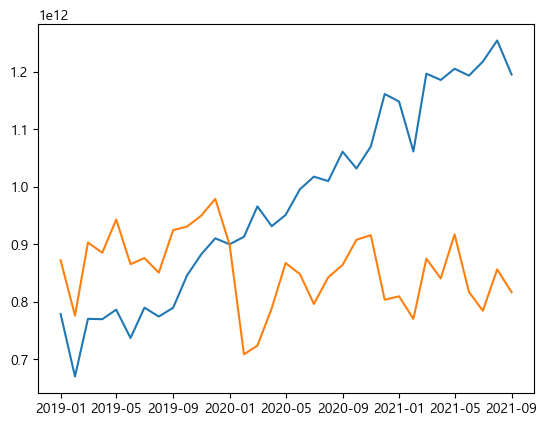

In [80]:
plt.plot(online_group)
plt.plot(offline_group)

In [81]:
# 파생변수 생성 -> on/off -> 온라인 1, 오프라인 0
# 업종 컬럼을 선택해서 map() 함수를 이용해서 온라인인지 판단 -> int() 변환해서 새로운 컬럼에 대입 
df['업종'].map(
    lambda x : int(x == '온라인')
)

0       0
1       0
2       0
3       0
4       0
       ..
3294    1
3295    1
3296    1
3297    1
3298    1
Name: 업종, Length: 3299, dtype: int64

In [82]:
# 한줄로 if문 표시 -> 참일경우결과 if 조건식 else 거짓인경우결과
df['on/off'] = df['업종'].map(
    lambda x : 'on' if x == '온라인' else 'off'
)

<Axes: xlabel='기준년월'>

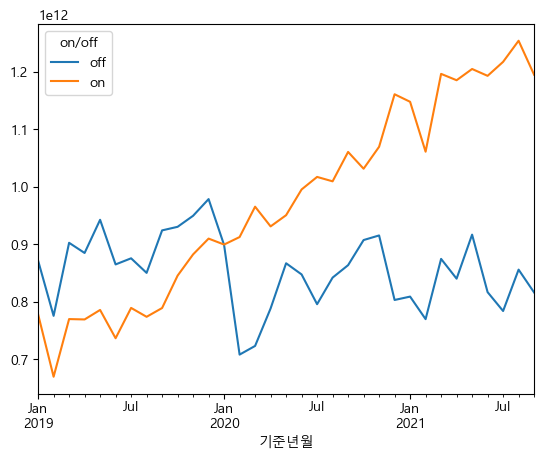

In [83]:
pd.pivot_table(
    df, 
    index = '기준년월', 
    columns = 'on/off', 
    values = '이용금액', 
    aggfunc= 'sum'
).plot()

In [84]:
# 기준년월, 업종을 기준으로 그룹화 이용금액의 합산 
group_data5 = df[ ['기준년월', '업종', '이용금액'] ].groupby( ['기준년월', '업종'] ).sum()

In [85]:
group_data5 = group_data5.unstack()

In [86]:
# group_data5에서 온라인 컬럼을 제외하고 나머지의 데이터들의 합산 오프라인 컬럼을 생성
group_data5 = group_data5['이용금액']

In [87]:
# 4개의 컬럼을 모두 더한다. 
group_data5['백화점'] + group_data5['할인점'] + group_data5['슈퍼마켓'] + group_data5['편의점']

기준년월
2019-01-01    8.717640e+11
2019-02-01    7.755979e+11
2019-03-01    9.027603e+11
2019-04-01    8.850403e+11
2019-05-01    9.427953e+11
2019-06-01    8.651183e+11
2019-07-01    8.757622e+11
2019-08-01    8.504003e+11
2019-09-01    9.243550e+11
2019-10-01    9.305846e+11
2019-11-01    9.497879e+11
2019-12-01    9.788397e+11
2020-01-01    8.988784e+11
2020-02-01    7.081442e+11
2020-03-01    7.232449e+11
2020-04-01    7.884697e+11
2020-05-01    8.671502e+11
2020-06-01    8.476832e+11
2020-07-01    7.958824e+11
2020-08-01    8.421567e+11
2020-09-01    8.638192e+11
2020-10-01    9.075381e+11
2020-11-01    9.155520e+11
2020-12-01    8.032242e+11
2021-01-01    8.091200e+11
2021-02-01    7.698808e+11
2021-03-01    8.747389e+11
2021-04-01    8.403269e+11
2021-05-01    9.169530e+11
2021-06-01    8.168673e+11
2021-07-01    7.840346e+11
2021-08-01    8.560545e+11
2021-09-01    8.163331e+11
dtype: float64

In [88]:
# 온라인 제외하고 모두 더한다. 
group_data5['오프라인'] = group_data5.drop('온라인', axis=1).sum(axis=1)

In [89]:
group_data5

업종,백화점,슈퍼마켓,온라인,편의점,할인점,오프라인
기준년월,,,,,,
2019-01-01,4.558955e+11,1.736131e+11,7.782817e+11,4.408358e+10,1.981718e+11,8.717640e+11
2019-02-01,4.011916e+11,1.546390e+11,6.696276e+11,4.019682e+10,1.795704e+11,7.755979e+11
2019-03-01,4.886521e+11,1.717930e+11,7.699826e+11,4.634686e+10,1.959683e+11,9.027603e+11
2019-04-01,4.536723e+11,1.741783e+11,7.693437e+11,5.093585e+10,2.062539e+11,8.850403e+11
2019-05-01,4.890036e+11,1.846895e+11,7.858765e+11,5.569127e+10,2.134109e+11,9.427953e+11
2019-06-01,4.325099e+11,1.874238e+11,7.366348e+11,5.559312e+10,1.895914e+11,8.651183e+11
2019-07-01,4.113440e+11,1.912817e+11,7.894194e+11,6.148315e+10,2.116533e+11,8.757622e+11
2019-08-01,3.939827e+11,1.983115e+11,7.739429e+11,6.140625e+10,1.966998e+11,8.504003e+11
2019-09-01,4.550747e+11,1.908706e+11,7.892287e+11,6.042129e+10,2.179884e+11,9.243550e+11


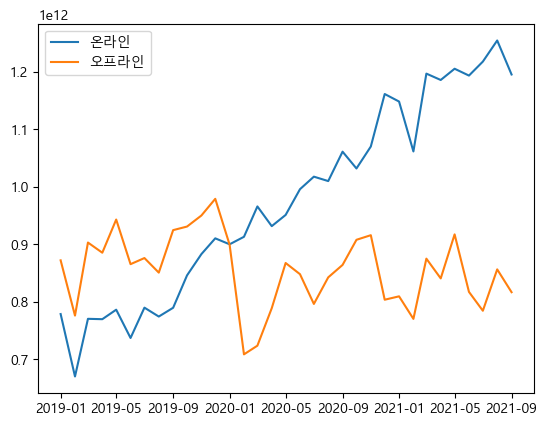

In [90]:
plt.plot(group_data5['온라인'])
plt.plot(group_data5['오프라인'])
plt.legend(['온라인', '오프라인'])
plt.show()

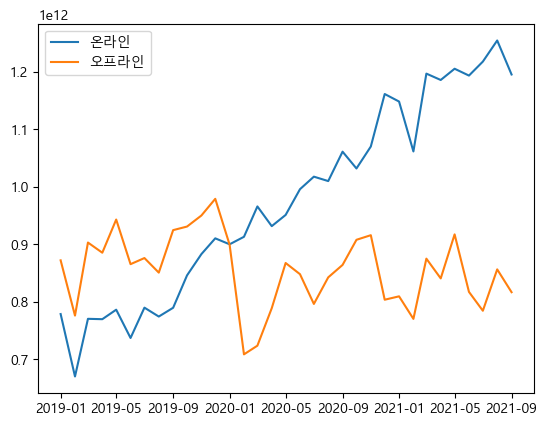

In [91]:
plt.plot(group_data5['온라인'], label='온라인')
plt.plot(group_data5['오프라인'], label='오프라인')
plt.legend()
plt.show()

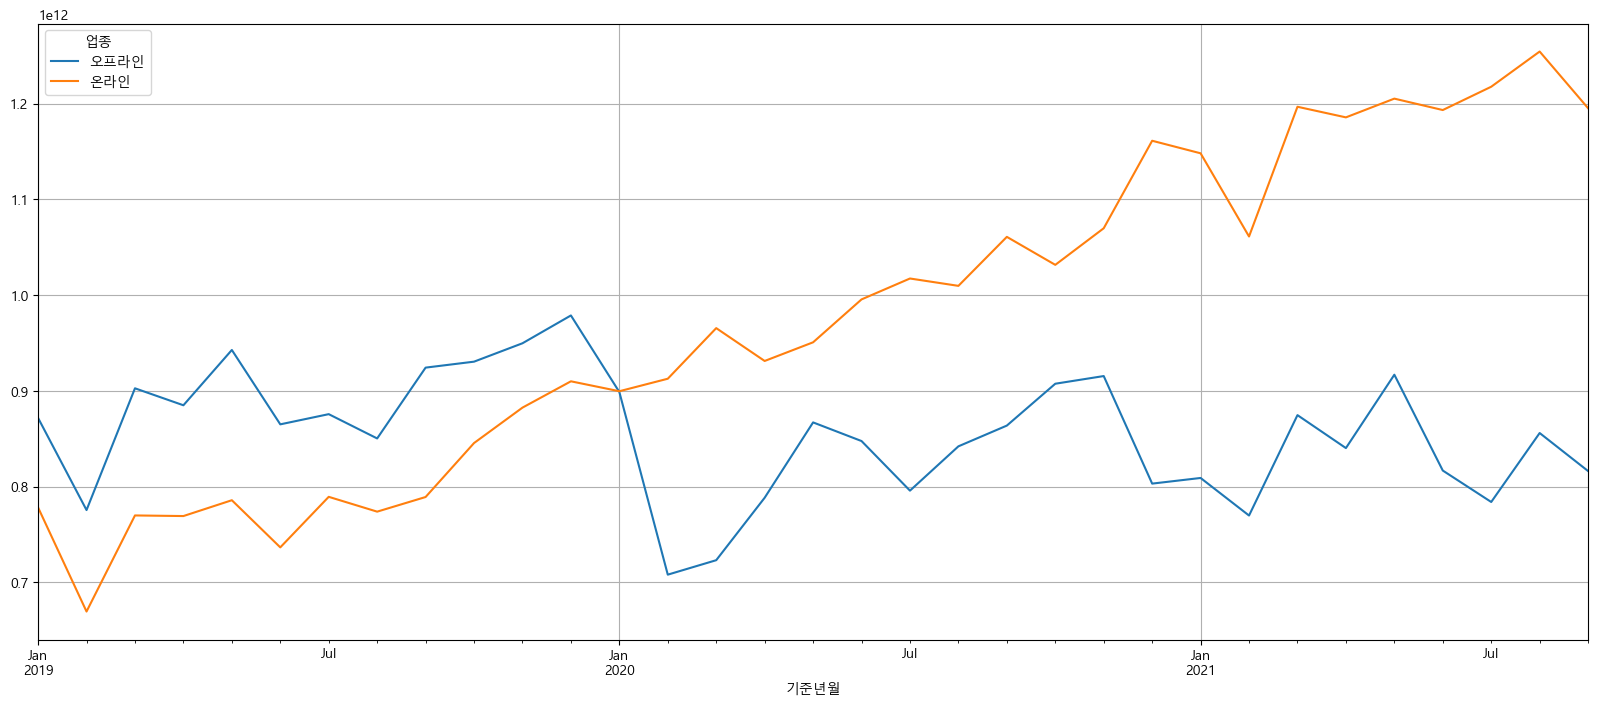

In [92]:
pd.pivot_table(
    df, 
    index = '기준년월', 
    columns = [df['업종'] == '온라인'], 
    values = '이용금액', 
    aggfunc= 'sum'
).rename(columns = {
    False : '오프라인', 
    True : '온라인'
}).plot(figsize = (20, 8))
plt.grid(True)